In [4]:
import pandas as pd
import re
from pathlib import Path
import ast

# ==========================================
# CONFIG
# ==========================================

folder = Path("Data/final_outputs")

materiality_map = {
    1: 2,
    2: 3,
    3: 4,
    4: 5,
    7: 5,
    8: 4,
    11: 5,
    12: 5,
    14: 5,
    15: 4,
    16: 4
}

all_targets = list(range(1, 24))

# Highest attainable index: every material target addressed by all
# three statement types -> (1 + 2 + 3) * sum of materiality weights.
MAX_INDEX = 6 * sum(materiality_map.values())

SMART_KEYS = [
    "Specific",
    "Measurable",
    "Achievable",
    "Relevant",
    "TimeBound"
]

# ==========================================
# HELPER
# ==========================================

def extract_targets(x):

    if pd.isna(x):
        return []

    nums = re.findall(r"\d+", str(x))

    return [
        int(n) for n in nums
        if 1 <= int(n) <= 23
    ]


def normalize_classification(x):

    x = str(x).strip().lower()

    if "smart" in x:
        return "SMART Target"

    if "commit" in x:
        return "Commitment"

    if "goal" in x:
        return "Goal"

    return x


def is_fully_smart(x):

    if pd.isna(x):
        return False

    flags = ast.literal_eval(str(x))

    return all(
        flags.get(k, False) for k in SMART_KEYS
    )


# ==========================================
# ANALYSE EACH COMPANY
# ==========================================

rows = []

for file in sorted(folder.glob("*.csv")):

    company = file.stem

    df = pd.read_csv(file)

    df.columns = df.columns.str.strip().str.lower()

    df = df.rename(
        columns={"gbf_targets": "gbf_target"}
    ).copy()

    # -------------------------
    # Clean GBF targets, then
    # keep only statements that
    # map to at least one target
    # -------------------------

    df["gbf_target"] = df["gbf_target"].apply(
        extract_targets
    )

    df = df[
        df["gbf_target"].apply(len) > 0
    ].copy()

    # Number of biodiversity statements
    # before exploding GBF targets
    num_statements = len(df)

    # -------------------------
    # Clean classification
    # -------------------------

    df["classification"] = (
        df["classification"]
        .apply(normalize_classification)
    )

    # If all SMART conditions are met,
    # classify it as a SMART Target
    # regardless of the LLM's own label.
    df.loc[
        df["smart"].apply(is_fully_smart),
        "classification"
    ] = "SMART Target"

    # -------------------------
    # Proportions
    # (per statement, before explode)
    # -------------------------

    total = len(df)

    goal_prop = (
        (df["classification"] == "Goal").sum()
        / total
        if total > 0 else 0
    )

    commitment_prop = (
        (df["classification"] == "Commitment").sum()
        / total
        if total > 0 else 0
    )

    smart_n = int(
        (df["classification"] == "SMART Target").sum()
    )

    smart_prop = (
        smart_n / total
        if total > 0 else 0
    )

    # -------------------------
    # Missing targets
    # -------------------------

    df = df.explode("gbf_target")

    df["gbf_target"] = (
        df["gbf_target"]
        .astype(int)
    )

    addressed = set(df["gbf_target"].unique())

    missing = sorted(
        set(materiality_map.keys()) - addressed
    )

    row = {
        "company": company,
        "num_statements": num_statements,
        "goal_prop": round(goal_prop, 4),
        "commitment_prop": round(commitment_prop, 4),
        "smart_prop": round(smart_prop, 4),
        "smart_n": smart_n,
        "missing_gbf_targets": missing
    }

    # -------------------------
    # GBF target summaries
    # -------------------------

    for target in all_targets:

        subset = df[
            df["gbf_target"] == target
        ]

        goals = (
            subset["classification"]
            == "Goal"
        ).sum()

        commitments = (
            subset["classification"]
            == "Commitment"
        ).sum()

        smarts = (
            subset["classification"]
            == "SMART Target"
        ).sum()

        row[f"GBF_{target}"] = [
            int(goals),
            int(commitments),
            int(smarts)
        ]

    # ==========================================
    # MATERIALITY WEIGHTED BIODIVERSITY INDEX
    # ==========================================

    biodiversity_index = 0

    for target in materiality_map.keys():

        subset = df[df["gbf_target"] == target]

        if len(subset) == 0:
            continue

        classifications_present = set(
            subset["classification"]
        )

        target_score = 0

        if "Goal" in classifications_present:
            target_score += 1

        if "Commitment" in classifications_present:
            target_score += 2

        if "SMART Target" in classifications_present:
            target_score += 3

        biodiversity_index += (
            target_score *
            materiality_map[target]
        )

    row["Biodiversity_Index"] = biodiversity_index

    row["Biodiversity_Index_Normalized"] = (
        biodiversity_index / MAX_INDEX
    )

    rows.append(row)

# ==========================================
# FINAL SUMMARY
# ==========================================

summary_df = pd.DataFrame(rows)

print(summary_df)

summary_df.to_csv(
    "company_biodiversity_summary.csv",
    index=False
)

                                  company  num_statements  goal_prop  \
0                 AIA Engineering 2024-25              46     0.4130   
1                        APL Apollo Tubes              63     0.7302   
2                       Aanchal Ispat Ltd               5     0.2000   
3                Abha Power and Steel Ltd              18     0.7778   
4                           Aditya Ispat                6     0.8333   
..                                    ...             ...        ...   
86                     Vaswani Industries               5     0.4000   
87                        Venus Pipes Ltd              43     0.5814   
88                 Vibhor Steel Tubes Ltd              12     0.4167   
89             Welcast Steels Ltd 2024-25               2     0.0000   
90  Zenith Steel Pipes and Industries Ltd               2     1.0000   

    commitment_prop  smart_prop  smart_n                  missing_gbf_targets  \
0            0.4348      0.1522        7              

Average Goal proportion        : 0.573
Average Commitment proportion  : 0.335
Average SMART Target proportion: 0.059


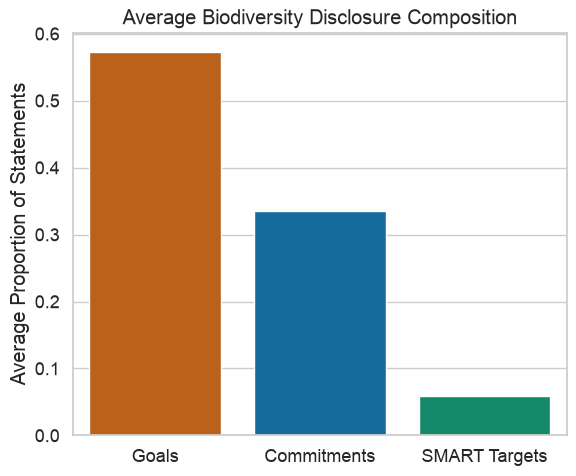

In [3]:
#-----CLASSIFICATION----
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.2)

df = pd.read_csv("company_biodiversity_summary.csv")

avg_goal = df["goal_prop"].mean()
avg_commitment = df["commitment_prop"].mean()
avg_smart = df["smart_prop"].mean()

print(f"Average Goal proportion        : {avg_goal:.3f}")
print(f"Average Commitment proportion  : {avg_commitment:.3f}")
print(f"Average SMART Target proportion: {avg_smart:.3f}")

avg_df = pd.DataFrame({
    "Classification":[
        "Goals",
        "Commitments",
        "SMART Targets"
    ],
    "Proportion":[
        avg_goal,
        avg_commitment,
        avg_smart
    ]
})

plt.figure(figsize=(6,5))

sns.barplot(
    data=avg_df,
    x="Classification",
    y="Proportion",
    hue="Classification",
    palette=["#D55E00","#0072B2","#009E73"],
    legend=False
)

plt.ylabel("Average Proportion of Statements")
plt.xlabel("")
plt.title("Average Biodiversity Disclosure Composition")

plt.tight_layout()

plt.show()

In [5]:
import pandas as pd
import ast
from collections import Counter

# ==========================
# LOAD DATA
# ==========================

df = pd.read_csv("company_biodiversity_summary.csv")

# Convert list stored as string to Python list
df["missing_gbf_targets"] = df["missing_gbf_targets"].apply(ast.literal_eval)

# =====================================
# 1. Average number of targets missed
# =====================================

df["n_missing"] = df["missing_gbf_targets"].apply(len)

avg_missing = df["n_missing"].mean()

print("="*50)
print(f"Average number of material targets missed: {avg_missing:.2f}")
print("="*50)

# =====================================
# 2. Companies that missed NO targets
# =====================================

no_missing = df[df["n_missing"] == 0]

print("\nCompanies with no missing material targets:\n")
print(no_missing[["company"]])

# =====================================
# 3. Companies missing MOST targets
# =====================================

most_missing = df.sort_values(
    "n_missing",
    ascending=False
)

print("\nTop companies with most missing targets:\n")
print(
    most_missing[
        ["company","n_missing"]
    ]
)

# =====================================
# 4. Which GBF target is missed most?
# =====================================

all_missing = []

for targets in df["missing_gbf_targets"]:
    all_missing.extend(targets)

target_frequency = (
    pd.Series(all_missing)
      .value_counts()
      .sort_index()
      .rename_axis("GBF Target")
      .reset_index(name="No_of_Companies_Missing")
)

print("\nMost missed GBF targets\n")
print(target_frequency.sort_values(
    "No_of_Companies_Missing",
    ascending=False
))

Average number of material targets missed: 5.47

Companies with no missing material targets:

                     company
8   Jindal Stainless 2024-25
40         JSW Steel 2024-25
59          APL Apollo Tubes
80           Tata Steel 2025

Top companies with most missing targets:

                         company  n_missing
21    Riddhi Steel and Tubes Ltd         11
5      Shri Bajrang Alliance Ltd         11
6             Deem Roll Tech Ltd         11
66              Dhatre Udyog Ltd         11
37            Remi Edelstahl Ltd         11
..                           ...        ...
79  Jayaswal Neco Industries Ltd          1
80               Tata Steel 2025          0
8       Jindal Stainless 2024-25          0
59              APL Apollo Tubes          0
40             JSW Steel 2024-25          0

[91 rows x 2 columns]

Most missed GBF targets

    GBF Target  No_of_Companies_Missing
2            3                       81
3            4                       75
7           12       